In [1]:
%%capture cap
%run desp-authentication.py

Username:  qinghuai925
Password:  ········


In [2]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

In [3]:
from pyproj import datadir
datadir.set_data_dir("/work/data/zhang/anaconda3/envs/earthkit/share/proj")
import earthkit.data
import earthkit.plots
import earthkit.regrid
from polytope.api import Client

import os
import os.path  # for basename
import sys
import glob
from pathlib import Path
import warnings
import datetime
import time  # for sleep

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from netCDF4 import Dataset
from PIL import Image

from mpl_toolkits.basemap import Basemap

import rasterio
from rasterio.transform import from_origin
from rasterio.merge import merge

from osgeo import gdal, osr, ogr  # Python bindings for GDAL
from global_land_mask import globe
from scipy.interpolate import griddata

from tqdm.auto import tqdm
from dask.diagnostics import ProgressBar

# utilities you mentioned using
from numpy import savetxt
import calendar

/work/data/zhang/anaconda3/envs/earthkit/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [4]:
# repo root: NOCOSRIOgit
repo_root = Path.cwd().resolve().parents[1]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [5]:
from common import download_icedata_c
from common import data_fetching
from common import config
from common import processing
from common.download_icedata_c import request_icedata_subarea

In [6]:
def request_icedata_subarea(activity,experiment,model,date,subarea,param,datadir=None):
	"""
	This function retrieves ClimateDT data
	#####
	- If a datadir is given, the function checks whether the desired data is already existing there.
	- Otherwise it will send a request to Polytope.
	- If a datadir is given and data was not existing there, the downloaded data will be saved for later use.
    
    Example usage:
    dataICE=request_icedata_subarea(activity="CMIP6",experiment="hist",model="ICON",
                                    date="2002-02-28",subarea="greenland", param="263001/263003/263004",
                                    datadir="/media/volume/")

    """
	
	# Set pre-defined download areas
	import earthkit.data
	if subarea in ["Greenland","greenland"]:
		area='85/-80/67/5'
	elif subarea in ["Arctic","arctic"]:
		area='90/-180/70/180'
	else:
		raise RuntimeError("Unknown subarea: "+ subarea+". Cannot create request.")
	
	# Check if data is already existing on disk
	filename='icedata_'+activity+'_'+experiment+'_'+model+'_'+date.replace("/","-")+'_'+subarea+'_'+param.replace("/","-")+'.grb'
	if datadir:
		print("Looking for previously downloaded data in: "+datadir)
		print("File name to look for: "+filename)
		try:
			dataICE=earthkit.data.from_source("file",datadir+"/"+filename)
		except FileNotFoundError:
			# File is not existing, hence download the data
			requestdata=True
		else:
			# No error, hence file was found, hence we don't need to download it
			print("Loading data from file:"+datadir+"/"+filename)
			requestdata=False
	else:
		requestdata=True
	
	# Request data from Polytope
	if requestdata==True: # No datadir given or file not existing in datadir => Will download data
		print("No datadir given or no existing data file found. I will request data from Polytope...")
		request = {
				"activity": activity,
				"class": "d1",
				"dataset": "climate-dt",
				"date": date,
				"experiment": experiment,
				"expver": "0001",
				"generation": "1",
				"levtype": "o2d",
				"model": model,
				"param": param,
				"realization": "1",
				"resolution": "high",
				"stream": "clte",
				"time": "0000",
				"type": "fc",
				'grid' : 'F512', # currently O, F, N grids are supported 
				'area' : area # e.g. '85/-80/67/5' # maxLAT, minLON, minLAT, maxLON
			}
		print(request)

		# Execute the download request
		#    data is an earthkit streaming object but with stream=False will download data immediately 
		dataICE = earthkit.data.from_source("polytope", "destination-earth", request, 
										address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)
	
		# Save data to disk for later use , if "datadir" is given
		if datadir:
			print("Saving data to: "+datadir+"/"+filename)
			dataICE.to_target("file",datadir+"/"+filename)
	
	return(dataICE)


In [7]:
def polaris(dattype,shipclass,season,*argv):
    if dattype == 'mod':
        if not len(argv)==3:
            raise RuntimeError("If DATTYPE is 'mod', then you have to provide 3 additional arguments: CCAT, HCAT and SCAT.")
        else:
            ccat=argv[0]
            hcat=argv[1]
            scat=argv[2]
        if np.sum(ccat) < 0.99:
            raise RuntimeError("The ice concentrations in CCAT does not sum up to 100%. Did you forget to include the open water fraction?")
    if dattype == 'modlim2':
        if not len(argv)==2:
            raise RuntimeError("If DATTYPE is 'modlim2', then you have to provide 2 additional arguments: CCAT and HCAT.")
        else:
            sic=argv[0]
            sit=argv[1]
        if np.sum(sic) < 0.99:
            raise RuntimeError("The ice concentrations in CCAT does not sum up to 100%. Did you forget to include the open water fraction?")
    elif dattype == 'hem':
        if not len(argv)==1:
            raise RuntimeError("If DATTYPE is 'hem', then you have to provide 1 additional argument: THICK")
        else:
            thick = argv[0]
    else:
        raise ValueError("DATTYPE has to be one of ['mod','modlim2','hem']")
                    
    if not (shipclass in ['PC1','PC2','PC3','PC4','PC5','PC6','PC7','1ASuper','1A','1B','1C','noclass']):
        raise ValueError("shipclass has to be one of ['PC1','PC2','PC3','PC4','PC5','PC6','PC7','1ASuper','1A','1B','1C','noclass']")
    # http://joshuakugler.com/archives/30-BetweenDict,-a-Python-dict-for-value-ranges.html
    class BetweenDict(dict):
        def __init__(self, d = {}):
            for k,v in d.items():
                self[k] = v
    
        def lookup(self, key):
            for k, v in self.items():
                if k[0] <= key < k[1]:
                    return v
            warnings.warn("Key '%s' is not between any values in the BetweenDict" % key)
            return {np.nan:np.nan} # Return a dictionary so that rv.lookup(thi[icl])[shipclass] will raise a KeyError.
#AGI            raise KeyError("Key '%s' is not between any values in the BetweenDict" % key)
    
        def setrange(self, key, value):
            try:
                if len(key) == 2:
                    if key[0] < key[1]:
                        dict.__setitem__(self, (key[0], key[1]), value)
                    else:
                        raise RuntimeError('First element of a BetweenDict key '
                                           'must be strictly less than the '
                                           'second element')
                else:
                    raise ValueError('Key of a BetweenDict must be an iterable '
                                     'with length two')
            except TypeError:
                raise TypeError('Key of a BetweenDict must be an iterable '
                                 'with length two')
    
        def __contains__(self, key):
            try:
                return bool(self[key]) or True
            except KeyError:
                return False
    
    # RV summer
    rvs = BetweenDict()
    rvs.setrange([0.  ,0.01],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':3,'PC7':3,  '1ASuper':3,'1A':3,'1B':3,'1C':3,'noclass':3}) # no ice
    rvs.setrange([0.01,0.10],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':2,'1C':2,'noclass':1}) # new ice
    rvs.setrange([0.10,0.15],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':2,'1C':1,'noclass':0}) # grey ice
    rvs.setrange([0.15,0.30],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':1,'1C':0,'noclass':-1}) # grey-white
    rvs.setrange([0.30,0.50],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':2,'PC7':1,  '1ASuper':2,'1A':1,'1B':0,'1C':-1,'noclass':-2}) # thin FY 1
    rvs.setrange([0.50,0.70],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':1,'PC7':1,  '1ASuper':1,'1A':0,'1B':-1,'1C':-2,'noclass':-3}) # thin FY 2
    rvs.setrange([0.70,0.95],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':2,'PC7':1,  '1ASuper':1,'1A':0,'1B':-1,'1C':-2,'noclass':-3}) # medium FY 1
    rvs.setrange([0.95,1.20],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':1,'PC7':0,  '1ASuper':0,'1A':-1,'1B':-2,'1C':-3,'noclass':-4}) # medium FY 2
    rvs.setrange([1.20,2.00],{'PC1':2,'PC2':2,'PC3':2,'PC4':1,'PC5':1,  'PC6':0,'PC7':-1,  '1ASuper':-1,'1A':-2,'1B':-3,'1C':-4,'noclass':-5}) # thick FY
    rvs.setrange([2.00,2.50],{'PC1':2,'PC2':1,'PC3':1,'PC4':0,'PC5':-1,  'PC6':-2,'PC7':-3,  '1ASuper':-3,'1A':-4,'1B':-5,'1C':-6,'noclass':-7}) # Second year ice
    rvs.setrange([2.50,3.00],{'PC1':1,'PC2':1,'PC3':0,'PC4':-1,'PC5':-2,  'PC6':-3,'PC7':-3,  '1ASuper':-4,'1A':-5,'1B':-6,'1C':-7,'noclass':-8}) # light MY
    rvs.setrange([3.00,99.9],{'PC1':1,'PC2':0,'PC3':-1,'PC4':-2,'PC5':-2,  'PC6':-3,'PC7':-3,  '1ASuper':-4,'1A':-5,'1B':-6,'1C':-8,'noclass':-8}) # heavy MY
    
    # RV winter
    rvw = BetweenDict()
    rvw.setrange([0.  ,0.01],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':3,'PC7':3,  '1ASuper':3,'1A':3,'1B':3,'1C':3,'noclass':3}) # no ice
    rvw.setrange([0.01,0.10],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':2,'1C':2,'noclass':1}) # new ice
    rvw.setrange([0.10,0.15],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':2,'1C':1,'noclass':0}) # grey ice
    rvw.setrange([0.15,0.30],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':1,'1C':0,'noclass':-1}) # grey-white
    rvw.setrange([0.30,0.50],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':2,'PC7':1,  '1ASuper':2,'1A':1,'1B':0,'1C':-1,'noclass':-2}) # thin FY 1
    rvw.setrange([0.50,0.70],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':1,'PC7':1,  '1ASuper':1,'1A':0,'1B':-1,'1C':-2,'noclass':-3}) # thin FY 2
    rvw.setrange([0.70,0.95],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':1,  'PC6':1,'PC7':0,  '1ASuper':0,'1A':-1,'1B':-2,'1C':-3,'noclass':-4}) # medium FY 1
    rvw.setrange([0.95,1.20],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':1,  'PC6':0,'PC7':-1,  '1ASuper':-1,'1A':-2,'1B':-3,'1C':-4,'noclass':-5}) # medium FY 2
    rvw.setrange([1.20,2.00],{'PC1':2,'PC2':2,'PC3':2,'PC4':1,'PC5':0,  'PC6':-1,'PC7':-2,  '1ASuper':-2,'1A':-3,'1B':-4,'1C':-5,'noclass':-6}) # thick FY
    rvw.setrange([2.00,2.50],{'PC1':2,'PC2':1,'PC3':1,'PC4':0,'PC5':-1,  'PC6':-2,'PC7':-3,  '1ASuper':-3,'1A':-4,'1B':-5,'1C':-6,'noclass':-7}) # Second year ice
    rvw.setrange([2.50,3.00],{'PC1':1,'PC2':1,'PC3':0,'PC4':-1,'PC5':-2,  'PC6':-3,'PC7':-3,  '1ASuper':-4,'1A':-5,'1B':-6,'1C':-7,'noclass':-8}) # light MY
    rvw.setrange([3.00,99.9],{'PC1':1,'PC2':0,'PC3':-1,'PC4':-2,'PC5':-2,  'PC6':-3,'PC7':-3,  '1ASuper':-4,'1A':-5,'1B':-6,'1C':-8,'noclass':-8}) # heavy MY
    
    if season in ['w','winter']:
        rv = rvw
    elif season in ['s','summer']:
        rv = rvs
    else:
        raise ValueError("season has to be one of ['winter','summer','w','s']")       
   
    if dattype == 'mod':
        # Part for MOD
        ##############
        thi=hcat + scat
        # RIO = (C1xRV1)+(C2xRV2)+(C3xRV3)+...(CnxRVn)
        rio = 0.
        for icl in range(len(ccat)): # 5 model ice categories
            try:
                rio += (10.*ccat[icl]) * rv.lookup(thi[icl])[shipclass] # *10 because C is in ice concentration in tenths.        
            except KeyError: # This happens if POLARIS get a NaN value (because of land grid cells). Then POLARIS's lookup returns an empty dictonary.
                return np.nan # Return NaN to keep land areas masked.
        return rio
 
    elif dattype == 'modlim2':
        # Part for MOD, artificially constructed from LIM2 grid cells
        ###############
        # RIO = (C1xRV1)+(C2xRV2)+(C3xRV3)+...(CnxRVn)
        rio = 0.
        for cellnum in range(len(sic)): # 5 model ice categories
            try:
                rio += (10.*sic[cellnum]) * rv.lookup(sit[cellnum])[shipclass] # *10 because C is in ice concentration in tenths.        
            except KeyError: # This happens if POLARIS get a NaN value (because of land grid cells). Then POLARIS's lookup returns an empty dictonary.
                return np.nan # Return NaN to keep land areas masked.
        return rio
        
    elif dattype == 'hem':
        # Part for HEM
        ###############
        binspolaris=[0.,0.01,0.10,0.15,0.30,0.50,0.70,0.95,1.20,2.00,2.50,3.00,99.9]
        hemdistpol = np.histogram(thick,bins=binspolaris)[0]
        hemconc = hemdistpol/float(np.sum(hemdistpol))
        rio = 0.
        for icl in range(0,len(binspolaris)-1): # 12 POLARIS ic2kyuT9_Kde types (not ship classes)
            binthick = binspolaris[icl]+0.001
            rio += (10.*hemconc[icl]) * rv.lookup(binthick)[shipclass] # *10 because C is in ice concentration in tenths
        return rio    


In [8]:
def addopenwater(siconcat,sithicat,*argv): # argv could be snthicat
    cww = np.array([1.-np.sum(siconcat)]+[x for x in siconcat])
    hww = np.array([0.]+[x for x in sithicat])
    if len(argv) == 0 :
        return (cww,hww)
    elif len(argv) == 1 :
        sww = np.array([0.]+[x for x in argv[0]])
        return (cww,hww,sww)
    else:
        raise RuntimeError('The function ADDOPENWATER can only be called with 2 or 3 arguments, not with: '+str(len(argv)))


In [9]:
riomapAGI = LinearSegmentedColormap.from_list('riomap', [(0. , 'red'),
                                                    (   0.3, 'red'),
                                                    (   0.5, 'yellow'),
                                                    (   0.7, 'green'),
                                                    (    1., 'green')])
                                                    
riomapAGI2 = LinearSegmentedColormap.from_list('riomap', [(0. , 'red'),
                                                (   0.0001, 'yellow'),
                                                (   0.5, 'yellow'),
                                                (   0.5001, 'lightgreen' ),
                                                (   0.9, 'green' ),
                                                (    1., (0.0,0.45,0.45))])                                                      
# Ice concentration
cdict1 = {'red':   ((0.0, 181./255.,181./255.),
               (0.25, 0.2, 0.2),
               (0.5, 0.2, 0.2),
               (1.0, 1.0, 1.0)),
     'green': ((0.0, 238./255, 238./255),
               (0.25, 0.2, 0.2),
               (0.5, 0.2, 0.2),
               (1.0, 1.0, 1.0)),
     'blue':  ((0.0, 1.0, 1.0),
               (0.25, 1.0, 1.0),
               (0.5, 0.2, 0.2),
               (1.0, 1.0, 1.0))
    }
eismapAGI = LinearSegmentedColormap('eismap', cdict1)   
############################################

In [10]:
# chart = earthkit.plots.Map(extent=[-180, 180,70, 90],crs=ccrs.PlateCarree())
# chart.grid_cells(
#     dataICE1month[0]
# )

# chart.title("sithick")
# chart.coastlines()
# chart.gridlines()
# chart.show()

In [11]:
# chart = earthkit.plots.Map(extent=[-180, 180,70, 90],crs=ccrs.PlateCarree())
# chart.grid_cells(
#     dataICE1month[1]
# )

# chart.title("siconc")
# chart.coastlines()
# chart.gridlines()
# chart.show()

In [12]:
# import os
# import numpy as np

# datastoragedir = '/work/data/zhang/NOCOSRIOgit/usecases/RIO/data'
# os.makedirs(datastoragedir, exist_ok=True)

# shipclass = 'PC5'   # unchanged

# def compute_rio_for_date(date_str):
#     dataICE1month = request_icedata_subarea(
#         activity='ScenarioMIP',
#         experiment='SSP3-7.0',
#         model='IFS-NEMO',
#         date=date_str,
#         subarea="arctic",
#         param="263000/263001",   # avg_siconc / avg_sithick
#         datadir=datastoragedir
#     )

#     ds = dataICE1month.to_xarray()

#     lat1d = ds["latitude"].values
#     lon1d = ds["longitude"].values
#     lat, lon = np.meshgrid(lat1d, lon1d, indexing="ij")

#     sic = np.ma.masked_invalid(ds["avg_siconc"].to_numpy())
#     sit = np.ma.masked_invalid(ds["avg_sithick"].to_numpy())

#     riotoplot = np.nan * np.zeros([sic.shape[0]-2, sic.shape[1]-2])

#     for jj in range(1, sic.shape[0]-1):
#         for ji in range(1, sic.shape[1]-1):
#             sic9 = 1.0/9.0 * sic[jj-1:jj+2, ji-1:ji+2].ravel()
#             sit9 =         sit[jj-1:jj+2, ji-1:ji+2].ravel()

#             if hasattr(sic9, "mask") and np.ma.getmaskarray(sic9).all():
#                 riotoplot[jj-1, ji-1] = np.nan
#             else:
#                 (plotcww, plothww) = addopenwater(sic9, sit9)
#                 riotoplot[jj-1, ji-1] = polaris('modlim2', shipclass, 'w', plotcww, plothww)

#     return riotoplot

# for year in range(2030, 2031):        # 2030..2039 inclusive
#     for month in range(1, 13):        # Jan..Dec
#         days_in_month = calendar.monthrange(year, month)[1]
#         for day in range(1, days_in_month + 1):
#             date_str = f"{year}{month:02d}{day:02d}"
#             outfile = os.path.join(datastoragedir, f"rio_{date_str}_F512.npy")

#             if os.path.exists(outfile):
#                 print(f"[{date_str}] exists, skipping.")
#                 continue

#             try:
#                 print(f"Processing {date_str} ...")
#                 riotoplot = compute_rio_for_date(date_str)  # expects 'YYYYMMDD'
#                 np.save(outfile, riotoplot)
#                 print(f"Saved {outfile}")
#             except Exception as e:
#                 print(f"[{date_str}] skipped due to error: {e}")
#                 continue


In [13]:
import os

datastoragedir = '/work/data/zhang/NOCOSRIOgit/usecases/RIO/data'
os.makedirs(datastoragedir, exist_ok=True)   # <-- create parents if missing
plotsdir = str(Path(datastoragedir).parent / "plots")

os.makedirs(plotsdir, exist_ok=True)

In [14]:
from pyproj import datadir
datadir.set_data_dir("/work/data/zhang/anaconda3/envs/earthkit/share/proj")


In [40]:

dataICE1month = request_icedata_subarea(
    activity='ScenarioMIP', experiment='SSP3-7.0', model='IFS-NEMO',
    date='20390801', subarea="arctic", param="263000/263001",
    datadir=datastoragedir
)
ds=dataICE1month.to_xarray()
lat1d = ds["latitude"].values      # (114,)
lon1d = ds["longitude"].values     # (2048,)

lat, lon = np.meshgrid(lat1d, lon1d, indexing="ij")  # -> (114, 2048)
sic = np.ma.masked_invalid(ds["avg_siconc"].to_numpy())
sit = np.ma.masked_invalid(ds["avg_sithick"].to_numpy())
shipclass= 'PC5'

riotoplot = np.nan*np.zeros([sic.shape[0]-2,sic.shape[1]-2])

for jj in range(1,sic.shape[0]-1):
    for ji in range(1,sic.shape[1]-1):
        sic9 = 1./9.*sic[jj-1:jj+2,ji-1:ji+2].ravel() # 9 adjacent values
        sit9 = sit[jj-1:jj+2,ji-1:ji+2].ravel() # 9 adjacent values
        if sic9.mask.all():
            riotoplot[jj-1,ji-1]=np.nan
# This does not work with the blue open water colour               elif sic9.sum() <=0.:
#                    riotoplot[jj-1,ji-1]=30.
        else:
            (plotcww, plothww) = addopenwater(sic9,sit9)        
            riotoplot[jj-1,ji-1]=polaris('modlim2',shipclass,'w',plotcww,plothww)
        
lonrio = lon[1:-1,1:-1]
latrio = lat[1:-1,1:-1] 


# After you've computed latrio, lonrio, and riotoplot:
outdir = Path(datastoragedir)  # reuse your existing variable
outdir.mkdir(parents=True, exist_ok=True)

# Save lat/lon as .npy (float32 keeps files smaller; change to float64 if you prefer)
np.save(outdir / "IFS-NEMO_latrio.npy", latrio.astype(np.float32))
np.save(outdir / "IFS-NEMO_lonrio.npy", lonrio.astype(np.float32))

print("Saved:",
      outdir / "IFS-NEMO_latrio.npy",
      outdir / "IFS-NEMO_lonrio.npy")


Looking for previously downloaded data in: /work/data/zhang/NOCOSRIOgit/usecases/RIO/data
File name to look for: icedata_ScenarioMIP_SSP3-7.0_IFS-NEMO_20390801_arctic_263000-263001.grb
Loading data from file:/work/data/zhang/NOCOSRIOgit/usecases/RIO/data/icedata_ScenarioMIP_SSP3-7.0_IFS-NEMO_20390801_arctic_263000-263001.grb


/tmp/ipykernel_1108886/1369601500.py:2: UserWarning: Warning: converting a masked element to nan.
  cww = np.array([1.-np.sum(siconcat)]+[x for x in siconcat])
/tmp/ipykernel_1108886/1369601500.py:3: UserWarning: Warning: converting a masked element to nan.
  hww = np.array([0.]+[x for x in sithicat])
/tmp/ipykernel_1108886/2476923275.py:39: UserWarning: Key 'nan' is not between any values in the BetweenDict
  warnings.warn("Key '%s' is not between any values in the BetweenDict" % key)


Saved: /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/IFS-NEMO_latrio.npy /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/IFS-NEMO_lonrio.npy


In [16]:
sit.shape

(114, 2048)

In [17]:
latrio.shape

(112, 2046)

In [18]:
import os
import re
import numpy as np
from pathlib import Path

datastoragedir = "/work/data/zhang/NOCOSRIOgit/usecases/RIO/data"
root = Path(datastoragedir)

pat = re.compile(r"^rio_(\d{4})(\d{2})(\d{2})(?:_F512)?\.npy$")

target_shape = (112, 2046)
sum_arr = None
count_arr = None
n_files = 0
skipped = 0
years_used = set()   # <--- track years that actually contribute to the mean

for p in root.glob("rio_*.npy"):
    m = pat.match(p.name)
    if not m:
        skipped += 1
        continue
    yyyy, mm, dd = m.groups()
    if mm != "04":
        continue

    arr = np.load(p, mmap_mode=None)
    if arr.shape != target_shape:
        print(f"[skip shape] {p.name} has {arr.shape}, expected {target_shape}")
        skipped += 1
        continue

    if sum_arr is None:
        sum_arr = np.zeros(target_shape, dtype=np.float64)
        count_arr = np.zeros(target_shape, dtype=np.int32)

    finite = np.isfinite(arr)
    sum_arr += np.where(finite, arr, 0.0)
    count_arr += finite.astype(np.int32)

    n_files += 1
    years_used.add(int(yyyy))   # <--- record this year
    if n_files % 25 == 0:
        print(f"Processed {n_files} April files...")

if n_files == 0:
    raise RuntimeError("No April files found matching rio_YYYYMMDD(_F512).npy")

mean_arr_apr = sum_arr / np.maximum(count_arr, 1)
mean_arr_apr[count_arr == 0] = np.nan

outpath = root / "rio_april_mean_F512.npy"
np.save(outpath, mean_arr_apr)

beginyear = min(years_used)     # <--- earliest year used
endyear = max(years_used)       # <--- latest year used

print(f"Done. April files used: {n_files}, skipped: {skipped}. Saved: {outpath}")
print("Result shape:", mean_arr_apr.shape, "dtype:", mean_arr_apr.dtype)
print(f"Year range used: {beginyear}-{endyear}")


Processed 25 April files...
Processed 50 April files...
Processed 75 April files...
Processed 100 April files...
Processed 125 April files...
Processed 150 April files...
Processed 175 April files...
Processed 200 April files...
Processed 225 April files...
Processed 250 April files...
Processed 275 April files...
Processed 300 April files...
Done. April files used: 300, skipped: 3656. Saved: /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/rio_april_mean_F512.npy
Result shape: (112, 2046) dtype: float64
Year range used: 2030-2039


In [19]:
import os
import re
import numpy as np
from pathlib import Path

datastoragedir = "/work/data/zhang/NOCOSRIOgit/usecases/RIO/data"
root = Path(datastoragedir)

pat = re.compile(r"^rio_(\d{4})(\d{2})(\d{2})(?:_F512)?\.npy$")

target_shape = (112, 2046)
sum_arr = None
count_arr = None
n_files = 0
skipped = 0
years_used = set()   # track years that actually contribute to the mean

for p in root.glob("rio_*.npy"):
    m = pat.match(p.name)
    if not m:
        skipped += 1
        continue
    yyyy, mm, dd = m.groups()
    if mm != "09":  # September
        continue

    arr = np.load(p, mmap_mode=None)
    if arr.shape != target_shape:
        print(f"[skip shape] {p.name} has {arr.shape}, expected {target_shape}")
        skipped += 1
        continue

    if sum_arr is None:
        sum_arr = np.zeros(target_shape, dtype=np.float64)
        count_arr = np.zeros(target_shape, dtype=np.int32)

    finite = np.isfinite(arr)
    sum_arr += np.where(finite, arr, 0.0)
    count_arr += finite.astype(np.int32)

    n_files += 1
    years_used.add(int(yyyy))   # record this year
    if n_files % 25 == 0:
        print(f"Processed {n_files} September files...")

if n_files == 0:
    raise RuntimeError("No September files found matching rio_YYYYMMDD(_F512).npy")

mean_arr_sep = sum_arr / np.maximum(count_arr, 1)
mean_arr_sep[count_arr == 0] = np.nan

outpath = root / "rio_september_mean_F512.npy"
np.save(outpath, mean_arr_sep)

beginyear = min(years_used)     # earliest year used
endyear = max(years_used)       # latest year used

print(f"Done. September files used: {n_files}, skipped: {skipped}. Saved: {outpath}")
print("Result shape:", mean_arr_sep.shape, "dtype:", mean_arr_sep.dtype)
print(f"Year range used: {beginyear}-{endyear}")


Processed 25 September files...
Processed 50 September files...
Processed 75 September files...
Processed 100 September files...
Processed 125 September files...
Processed 150 September files...
Processed 175 September files...
Processed 200 September files...
Processed 225 September files...
Processed 250 September files...
Processed 275 September files...
Processed 300 September files...
Done. September files used: 300, skipped: 3656. Saved: /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/rio_september_mean_F512.npy
Result shape: (112, 2046) dtype: float64
Year range used: 2030-2039


In [22]:
datatoplot=mean_arr_apr
lontoplot=lonrio
lattoplot=latrio
climateDTmodel='IFS-NEMO'

In [41]:
lattoplot

array([[89.86550869, 89.86550869, 89.86550869, ..., 89.86550869,
        89.86550869, 89.86550869],
       [89.69128632, 89.69128632, 89.69128632, ..., 89.69128632,
        89.69128632, 89.69128632],
       [89.51603507, 89.51603507, 89.51603507, ..., 89.51603507,
        89.51603507, 89.51603507],
       ...,
       [70.36601308, 70.36601308, 70.36601308, ..., 70.36601308,
        70.36601308, 70.36601308],
       [70.19031781, 70.19031781, 70.19031781, ..., 70.19031781,
        70.19031781, 70.19031781],
       [70.01462253, 70.01462253, 70.01462253, ..., 70.01462253,
        70.01462253, 70.01462253]], shape=(114, 2048))

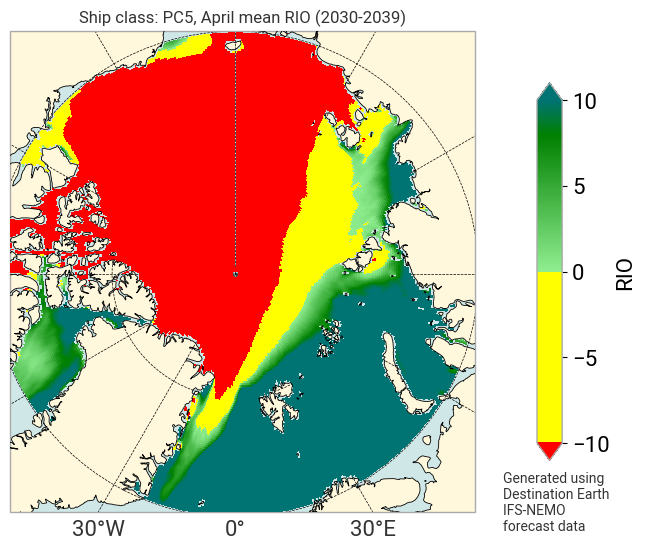

In [24]:
# --- colors (pick what you like) ---
ocean_fc = "#cfe7e7"
land_fc  = "cornsilk"

ax = plt.axes(projection=ccrs.Orthographic(central_longitude=0.0, central_latitude=90))
ax.set_extent([-180, 180, 70, 90], crs=ccrs.PlateCarree())

# 0) ocean base (lowest)
# either set the axes background facecolor:
ax.set_facecolor(ocean_fc)
# (or use the ocean feature)
# ax.add_feature(cfeature.OCEAN, facecolor=ocean_fc, zorder=0)

# 1) land fill (below grid + RIO)
ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=1)

# 2) grid lines (above ocean+land, below RIO)
parallels = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="black",
    alpha=1,
    linestyle="--",
    zorder=2,
)
parallels.ylocator = plt.FixedLocator(range(40, 90, 10))
parallels.xlocator = plt.FixedLocator(range(-180, 180, 30))
parallels.top_labels = False
parallels.xlabel_style = {'fontsize': 16}
parallels.ylabel_style = {'fontsize': 16}

# 3) RIO field (top of fills & grid)
pcolorhandle2 = ax.pcolormesh(
    lontoplot, lattoplot, datatoplot,
    cmap=riomapAGI2, vmin=-10, vmax=10,
    transform=ccrs.PlateCarree(),
    linewidth=0, rasterized=True,
    zorder=3,
)

# 4) coastlines on top for crisp edges
ax.coastlines(resolution="50m", linewidth=0.6, zorder=4)

# colorbar, title, etc. unchanged
cbar = plt.colorbar(pcolorhandle2, shrink=0.7, pad=0.1, aspect=15, extend='both')
cbar.ax.tick_params(labelsize=16)
cbar.set_label('RIO', fontsize=16)
plt.text(2400000,-2300000,'Generated using\nDestination Earth \n'+climateDTmodel+' \nforecast data',fontsize=10)    
plt.title(f"Ship class: {shipclass}, April mean RIO ({beginyear}-{endyear})")
plt.savefig(os.path.join(plotsdir, f"S2S_RIO_{shipclass}_april_mean_{beginyear}-{endyear}.png"),
            dpi=300, bbox_inches="tight")


In [25]:
datatoplot=mean_arr_sep
lontoplot=lonrio
lattoplot=latrio
climateDTmodel='IFS-NEMO'

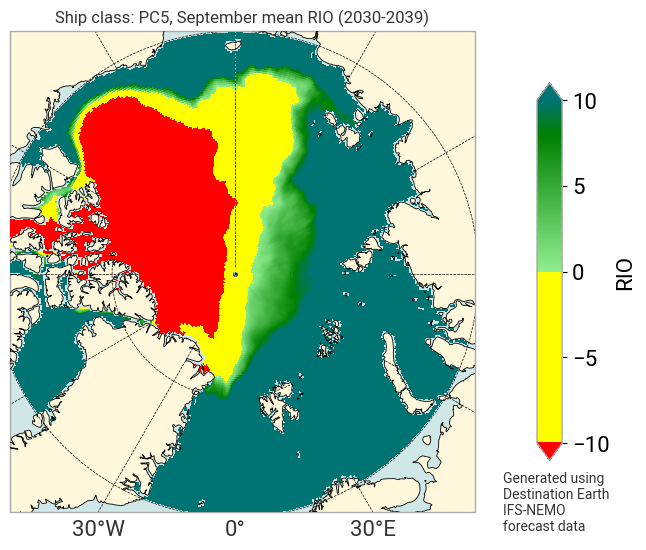

In [26]:
from matplotlib.ticker import FixedLocator  # <-- use this, not plt.FixedLocator

# --- colors (pick what you like) ---
ocean_fc = "#cfe7e7"
land_fc  = "cornsilk"

ax = plt.axes(projection=ccrs.Orthographic(central_longitude=0.0, central_latitude=90))
ax.set_extent([-180, 180, 70, 90], crs=ccrs.PlateCarree())

# 0) ocean base (lowest)
ax.set_facecolor(ocean_fc)
# ax.add_feature(cfeature.OCEAN, facecolor=ocean_fc, zorder=0)

# 1) land fill (below grid + RIO)
ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=1)

# 2) grid lines (above ocean+land, below RIO)
parallels = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="black",
    alpha=1,
    linestyle="--",
    zorder=2,
)
parallels.ylocator = FixedLocator(range(40, 90, 10))
parallels.xlocator = FixedLocator(range(-180, 180, 30))
parallels.top_labels = False
parallels.xlabel_style = {'fontsize': 16}
parallels.ylabel_style = {'fontsize': 16}

# 3) RIO field (top of fills & grid)
pcolorhandle2 = ax.pcolormesh(
    lontoplot, lattoplot, datatoplot,
    cmap=riomapAGI2, vmin=-10, vmax=10,
    transform=ccrs.PlateCarree(),
    linewidth=0, rasterized=True,
    zorder=3,
)

# 4) coastlines on top for crisp edges
ax.coastlines(resolution="50m", linewidth=0.6, zorder=4)

# colorbar, title, etc.
cbar = plt.colorbar(pcolorhandle2, shrink=0.7, pad=0.1, aspect=15, extend='both')
cbar.ax.tick_params(labelsize=16)
cbar.set_label('RIO', fontsize=16)

plt.text(2400000, -2300000,
         'Generated using\nDestination Earth \n' + climateDTmodel + ' \nforecast data',
         fontsize=10)

plt.title(f"Ship class: {shipclass}, September mean RIO ({beginyear}-{endyear})")

plt.savefig(
    os.path.join(plotsdir, f"S2S_RIO_{shipclass}_september_mean_{beginyear}-{endyear}.png"),
    dpi=300, bbox_inches="tight"
)


In [58]:
# # --- colors (pick what you like) ---
# ocean_fc = "#cfe7e7"
# land_fc  = "cornsilk"

# ax = plt.axes(projection=ccrs.Orthographic(central_longitude=0.0, central_latitude=90))
# ax.set_extent([-180, 180, 70, 90], crs=ccrs.PlateCarree())

# # 0) ocean base (lowest)
# # either set the axes background facecolor:
# ax.set_facecolor(ocean_fc)
# # (or use the ocean feature)
# # ax.add_feature(cfeature.OCEAN, facecolor=ocean_fc, zorder=0)

# # 1) land fill (below grid + RIO)
# ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=1)

# # 2) grid lines (above ocean+land, below RIO)
# parallels = ax.gridlines(
#     crs=ccrs.PlateCarree(),
#     draw_labels=True,
#     linewidth=0.5,
#     color="black",
#     alpha=1,
#     linestyle="--",
#     zorder=2,
# )
# parallels.ylocator = plt.FixedLocator(range(40, 90, 10))
# parallels.xlocator = plt.FixedLocator(range(-180, 180, 30))
# parallels.top_labels = False
# parallels.xlabel_style = {'fontsize': 16}
# parallels.ylabel_style = {'fontsize': 16}

# # 3) RIO field (top of fills & grid)
# pcolorhandle2 = ax.pcolormesh(
#     lon, lat, sit,
#     cmap='Blues_r', vmin=0, vmax=4,
#     transform=ccrs.PlateCarree(),
#     linewidth=0, rasterized=True,
#     zorder=3,
# )

# # 4) coastlines on top for crisp edges
# ax.coastlines(resolution="50m", linewidth=0.6, zorder=4)

# # colorbar, title, etc. unchanged
# cbar = plt.colorbar(pcolorhandle2, shrink=0.7, pad=0.1, aspect=15, extend='both')
# cbar.ax.tick_params(labelsize=16)
# cbar.set_label('SIT', fontsize=16)
# plt.text(2400000,-2300000,'Generated using\nDestination Earth \n'+climateDTmodel+' \nforecast data',fontsize=10)    
# plt.title(f"Sea Ice Thickness 20390801")



In [30]:
# Aggregate April means (SIC/SIT) from:
# icedata_ScenarioMIP_SSP3-7.0_IFS-NEMO_YYYY04DD_arctic_263000-263001.grb

from pathlib import Path
import re
import numpy as np
import earthkit.data as ekd

datadir = Path("/work/data/zhang/NOCOSRIOgit/usecases/RIO/data")

# Match both "..._arctic_..." and "..._Arctic_..." just in case
pat = re.compile(
    r"^icedata_ScenarioMIP_SSP3-7\.0_IFS-NEMO_(\d{4})04(\d{2})_(?:arctic|Arctic)_263000-263001\.grb$"
)

def read_grib_to_xarray(path: Path):
    ds = ekd.from_source("file", str(path))
    return ds.to_xarray()

def get_first_var(ds, candidates):
    """Return the first existing variable name from candidates."""
    for name in candidates:
        if name in ds:
            return ds[name]
    raise KeyError(f"None of {candidates} found in dataset variables: {list(ds.data_vars)}")

# --- accumulators ---
sum_sic = sum_sit = None
cnt_sic = cnt_sit = None
lat_ref = lon_ref = None
n_files = 0
skipped = 0
years = set()

# Broad glob; regex filters to April IFS-NEMO Arctic files
for p in sorted(datadir.glob("icedata_ScenarioMIP_SSP3-7.0_IFS-NEMO_*_263000-263001.grb")):
    m = pat.match(p.name)
    if not m:
        skipped += 1
        continue

    yyyy, dd = m.groups()
    years.add(int(yyyy))

    ds = read_grib_to_xarray(p)

    # Coords
    lat1d = ds["latitude"].values
    lon1d = ds["longitude"].values
    lat, lon = np.meshgrid(lat1d, lon1d, indexing="ij")  # (nlat, nlon)

    # Variables (be tolerant to naming)
    sic_da = get_first_var(ds, ["avg_siconc", "siconc", "sea_ice_area_fraction"])
    sit_da = get_first_var(ds, ["avg_sithick", "sithick", "sea_ice_thickness"])

    sic = np.ma.masked_invalid(sic_da.to_numpy())
    sit = np.ma.masked_invalid(sit_da.to_numpy())

    # Init accumulators
    if sum_sic is None:
        sum_sic = np.zeros_like(sic, dtype=np.float64)
        sum_sit = np.zeros_like(sit, dtype=np.float64)
        cnt_sic = np.zeros_like(sic, dtype=np.int32)
        cnt_sit = np.zeros_like(sit, dtype=np.int32)
        lat_ref, lon_ref = lat.copy(), lon.copy()
    else:
        # sanity: same grid
        if (
            lat.shape != lat_ref.shape or lon.shape != lon_ref.shape
            or not np.allclose(lat, lat_ref)
            or not np.allclose(lon, lon_ref)
        ):
            print(f"[skip grid] {p.name} grid differs from first file")
            skipped += 1
            continue

    # Accumulate with finite masks
    finite_sic = np.isfinite(sic)
    sum_sic += np.where(finite_sic, sic, 0.0)
    cnt_sic += finite_sic.astype(np.int32)

    finite_sit = np.isfinite(sit)
    sum_sit += np.where(finite_sit, sit, 0.0)
    cnt_sit += finite_sit.astype(np.int32)

    n_files += 1
    if n_files % 25 == 0:
        print(f"Processed {n_files} April files...")

if n_files == 0:
    raise RuntimeError(
        "No April GRIB files found matching icedata_ScenarioMIP_SSP3-7.0_IFS-NEMO_yyyy04dd_[Aa]rctic_263000-263001.grb"
    )

# Means (NaN where no valid samples)
mean_sic = sum_sic / np.maximum(cnt_sic, 1)
mean_sic[cnt_sic == 0] = np.nan

mean_sit = sum_sit / np.maximum(cnt_sit, 1)
mean_sit[cnt_sit == 0] = np.nan

# Save
out_npz = datadir / "IFS-NEMO_SSP3-7.0_april_mean_sic_sit.npz"
np.savez_compressed(
    out_npz,
    lat=lat_ref, lon=lon_ref,
    mean_sic=mean_sic, count_sic=cnt_sic,
    mean_sit=mean_sit, count_sit=cnt_sit,
    years_sorted=np.array(sorted(years), dtype=np.int16),
)

print(f"Done. Used files: {n_files}, skipped: {skipped}.")
print(f"Saved: {out_npz}")
print(f"Grid: {mean_sic.shape}, years: {min(years)}–{max(years)}")


Processed 25 April files...
Processed 50 April files...
Processed 75 April files...
Processed 100 April files...
Processed 125 April files...
Processed 150 April files...
Processed 175 April files...
Processed 200 April files...
Processed 225 April files...
Processed 250 April files...
Processed 275 April files...
Processed 300 April files...
Done. Used files: 300, skipped: 3323.
Saved: /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/IFS-NEMO_SSP3-7.0_april_mean_sic_sit.npz
Grid: (114, 2048), years: 2030–2039


In [1]:
datatoplot=mean_sit
lontoplot=lon
lattoplot=lat
# --- colors (pick what you like) ---
ocean_fc = "#cfe7e7"
land_fc  = "cornsilk"

ax = plt.axes(projection=ccrs.Orthographic(central_longitude=0.0, central_latitude=90))
ax.set_extent([-180, 180, 70, 90], crs=ccrs.PlateCarree())

# 0) ocean base (lowest)
# either set the axes background facecolor:
ax.set_facecolor(ocean_fc)
# (or use the ocean feature)
# ax.add_feature(cfeature.OCEAN, facecolor=ocean_fc, zorder=0)

# 1) land fill (below grid + RIO)
ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=1)

# 2) grid lines (above ocean+land, below RIO)
parallels = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="black",
    alpha=1,
    linestyle="--",
    zorder=2,
)
parallels.ylocator = plt.FixedLocator(range(40, 90, 10))
parallels.xlocator = plt.FixedLocator(range(-180, 180, 30))
parallels.top_labels = False
parallels.xlabel_style = {'fontsize': 16}
parallels.ylabel_style = {'fontsize': 16}

# 3) RIO field (top of fills & grid)
pcolorhandle2 = ax.pcolormesh(
    lontoplot, lattoplot, datatoplot,
    cmap='Blues_r', vmin=0, vmax=2,
    transform=ccrs.PlateCarree(),
    linewidth=0, rasterized=True,
    zorder=3,
)

# 4) coastlines on top for crisp edges
ax.coastlines(resolution="50m", linewidth=0.6, zorder=4)

# colorbar, title, etc. unchanged
cbar = plt.colorbar(pcolorhandle2, shrink=0.7, pad=0.1, aspect=15, extend='both')
cbar.ax.tick_params(labelsize=16)
cbar.set_label('SIT', fontsize=16)
plt.text(2400000,-2300000,'Generated using\nDestination Earth \n'+climateDTmodel+' \nforecast data',fontsize=10)    
plt.title(f"Sea Ice Thickness April mean(2030-2039)")


NameError: name 'mean_sit' is not defined

Text(0.5, 1.0, 'Sea Ice Concentration April mean(2030-2039)')

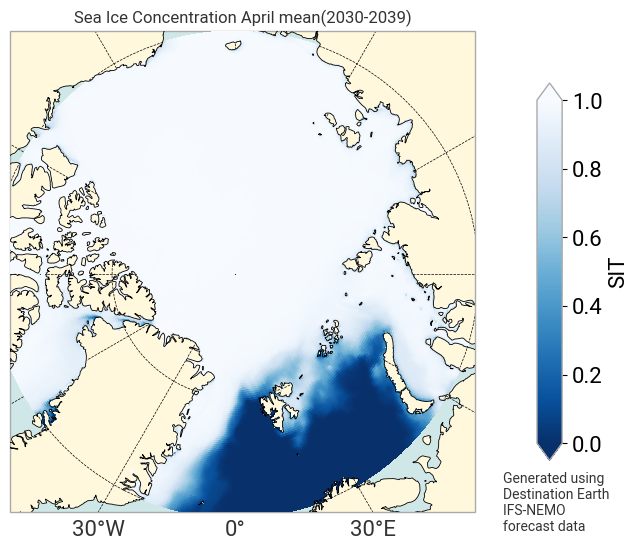

In [32]:
datatoplot=mean_sic
lontoplot=lon
lattoplot=lat
# --- colors (pick what you like) ---
ocean_fc = "#cfe7e7"
land_fc  = "cornsilk"

ax = plt.axes(projection=ccrs.Orthographic(central_longitude=0.0, central_latitude=90))
ax.set_extent([-180, 180, 70, 90], crs=ccrs.PlateCarree())

# 0) ocean base (lowest)
# either set the axes background facecolor:
ax.set_facecolor(ocean_fc)
# (or use the ocean feature)
# ax.add_feature(cfeature.OCEAN, facecolor=ocean_fc, zorder=0)

# 1) land fill (below grid + RIO)
ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=1)

# 2) grid lines (above ocean+land, below RIO)
parallels = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="black",
    alpha=1,
    linestyle="--",
    zorder=2,
)
parallels.ylocator = plt.FixedLocator(range(40, 90, 10))
parallels.xlocator = plt.FixedLocator(range(-180, 180, 30))
parallels.top_labels = False
parallels.xlabel_style = {'fontsize': 16}
parallels.ylabel_style = {'fontsize': 16}

# 3) RIO field (top of fills & grid)
pcolorhandle2 = ax.pcolormesh(
    lontoplot, lattoplot, datatoplot,
    cmap='Blues_r', vmin=0, vmax=1,
    transform=ccrs.PlateCarree(),
    linewidth=0, rasterized=True,
    zorder=3,
)

# 4) coastlines on top for crisp edges
ax.coastlines(resolution="50m", linewidth=0.6, zorder=4)

# colorbar, title, etc. unchanged
cbar = plt.colorbar(pcolorhandle2, shrink=0.7, pad=0.1, aspect=15, extend='both')
cbar.ax.tick_params(labelsize=16)
cbar.set_label('SIT', fontsize=16)
plt.text(2400000,-2300000,'Generated using\nDestination Earth \n'+climateDTmodel+' \nforecast data',fontsize=10)    
plt.title(f"Sea Ice Concentration April mean(2030-2039)")


In [33]:
# Aggregate September means (SIC/SIT) from:
# icedata_ScenarioMIP_SSP3-7.0_IFS-NEMO_YYYY09DD_arctic_263000-263001.grb

from pathlib import Path
import re
import numpy as np
import earthkit.data as ekd
import calendar

datadir = Path("/work/data/zhang/NOCOSRIOgit/usecases/RIO/data")

# ---- month switch ----
MONTH = "09"                         # "04"=Apr, "09"=Sep, etc.
MONTH_NAME = calendar.month_name[int(MONTH)]  # "September"

pat = re.compile(
    rf"^icedata_ScenarioMIP_SSP3-7\.0_IFS-NEMO_(\d{{4}}){MONTH}(\d{{2}})_(?:arctic|Arctic)_263000-263001\.grb$"
)

def read_grib_to_xarray(path: Path):
    return ekd.from_source("file", str(path)).to_xarray()

def get_first_var(ds, candidates):
    for name in candidates:
        if name in ds:
            return ds[name]
    raise KeyError(f"None of {candidates} found in dataset variables: {list(ds.data_vars)}")

# --- accumulators ---
sum_sic = sum_sit = None
cnt_sic = cnt_sit = None
lat_ref = lon_ref = None
n_files = 0
skipped = 0
years = set()

for p in sorted(datadir.glob("icedata_ScenarioMIP_SSP3-7.0_IFS-NEMO_*_263000-263001.grb")):
    m = pat.match(p.name)
    if not m:
        skipped += 1
        continue

    yyyy, dd = m.groups()
    years.add(int(yyyy))

    ds = read_grib_to_xarray(p)

    lat1d = ds["latitude"].values
    lon1d = ds["longitude"].values
    lat, lon = np.meshgrid(lat1d, lon1d, indexing="ij")  # (nlat, nlon)

    sic_da = get_first_var(ds, ["avg_siconc", "siconc", "sea_ice_area_fraction"])
    sit_da = get_first_var(ds, ["avg_sithick", "sithick", "sea_ice_thickness"])

    sic = np.ma.masked_invalid(sic_da.to_numpy())
    sit = np.ma.masked_invalid(sit_da.to_numpy())

    if sum_sic is None:
        sum_sic = np.zeros_like(sic, dtype=np.float64)
        sum_sit = np.zeros_like(sit, dtype=np.float64)
        cnt_sic = np.zeros_like(sic, dtype=np.int32)
        cnt_sit = np.zeros_like(sit, dtype=np.int32)
        lat_ref, lon_ref = lat.copy(), lon.copy()
    else:
        if (
            lat.shape != lat_ref.shape or lon.shape != lon_ref.shape
            or not np.allclose(lat, lat_ref) or not np.allclose(lon, lon_ref)
        ):
            print(f"[skip grid] {p.name} grid differs from first file")
            skipped += 1
            continue

    finite_sic = np.isfinite(sic)
    sum_sic += np.where(finite_sic, sic, 0.0)
    cnt_sic += finite_sic.astype(np.int32)

    finite_sit = np.isfinite(sit)
    sum_sit += np.where(finite_sit, sit, 0.0)
    cnt_sit += finite_sit.astype(np.int32)

    n_files += 1
    if n_files % 25 == 0:
        print(f"Processed {n_files} {MONTH_NAME} files...")

if n_files == 0:
    raise RuntimeError(
        f"No {MONTH_NAME} GRIB files found matching "
        f"icedata_ScenarioMIP_SSP3-7.0_IFS-NEMO_yyyy{MONTH}dd_[Aa]rctic_263000-263001.grb"
    )

mean_sic = sum_sic / np.maximum(cnt_sic, 1)
mean_sic[cnt_sic == 0] = np.nan

mean_sit = sum_sit / np.maximum(cnt_sit, 1)
mean_sit[cnt_sit == 0] = np.nan

out_npz = datadir / f"IFS-NEMO_SSP3-7.0_{MONTH_NAME.lower()}_mean_sic_sit.npz"
np.savez_compressed(
    out_npz,
    lat=lat_ref, lon=lon_ref,
    mean_sic=mean_sic, count_sic=cnt_sic,
    mean_sit=mean_sit, count_sit=cnt_sit,
    years_sorted=np.array(sorted(years), dtype=np.int16),
)

print(f"Done. Used files: {n_files}, skipped: {skipped}.")
print(f"Saved: {out_npz}")
print(f"Grid: {mean_sic.shape}, years: {min(years)}–{max(years)}")


Processed 25 September files...
Processed 50 September files...
Processed 75 September files...
Processed 100 September files...
Processed 125 September files...
Processed 150 September files...
Processed 175 September files...
Processed 200 September files...
Processed 225 September files...
Processed 250 September files...
Processed 275 September files...
Processed 300 September files...
Done. Used files: 300, skipped: 3323.
Saved: /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/IFS-NEMO_SSP3-7.0_september_mean_sic_sit.npz
Grid: (114, 2048), years: 2030–2039


Text(0.5, 1.0, 'Sea Ice Thickness September mean(2030-2039)')

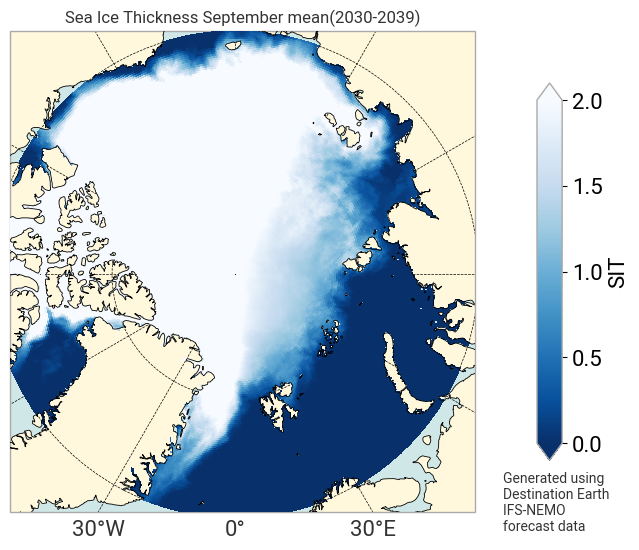

In [34]:
datatoplot=mean_sit
lontoplot=lon
lattoplot=lat
# --- colors (pick what you like) ---
ocean_fc = "#cfe7e7"
land_fc  = "cornsilk"

ax = plt.axes(projection=ccrs.Orthographic(central_longitude=0.0, central_latitude=90))
ax.set_extent([-180, 180, 70, 90], crs=ccrs.PlateCarree())

# 0) ocean base (lowest)
# either set the axes background facecolor:
ax.set_facecolor(ocean_fc)
# (or use the ocean feature)
# ax.add_feature(cfeature.OCEAN, facecolor=ocean_fc, zorder=0)

# 1) land fill (below grid + RIO)
ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=1)

# 2) grid lines (above ocean+land, below RIO)
parallels = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="black",
    alpha=1,
    linestyle="--",
    zorder=2,
)
parallels.ylocator = plt.FixedLocator(range(40, 90, 10))
parallels.xlocator = plt.FixedLocator(range(-180, 180, 30))
parallels.top_labels = False
parallels.xlabel_style = {'fontsize': 16}
parallels.ylabel_style = {'fontsize': 16}

# 3) RIO field (top of fills & grid)
pcolorhandle2 = ax.pcolormesh(
    lontoplot, lattoplot, datatoplot,
    cmap='Blues_r', vmin=0, vmax=2,
    transform=ccrs.PlateCarree(),
    linewidth=0, rasterized=True,
    zorder=3,
)

# 4) coastlines on top for crisp edges
ax.coastlines(resolution="50m", linewidth=0.6, zorder=4)

# colorbar, title, etc. unchanged
cbar = plt.colorbar(pcolorhandle2, shrink=0.7, pad=0.1, aspect=15, extend='both')
cbar.ax.tick_params(labelsize=16)
cbar.set_label('SIT', fontsize=16)
plt.text(2400000,-2300000,'Generated using\nDestination Earth \n'+climateDTmodel+' \nforecast data',fontsize=10)    
plt.title(f"Sea Ice Thickness September mean(2030-2039)")

Text(0.5, 1.0, 'Sea Ice Concentration April mean(2030-2039)')

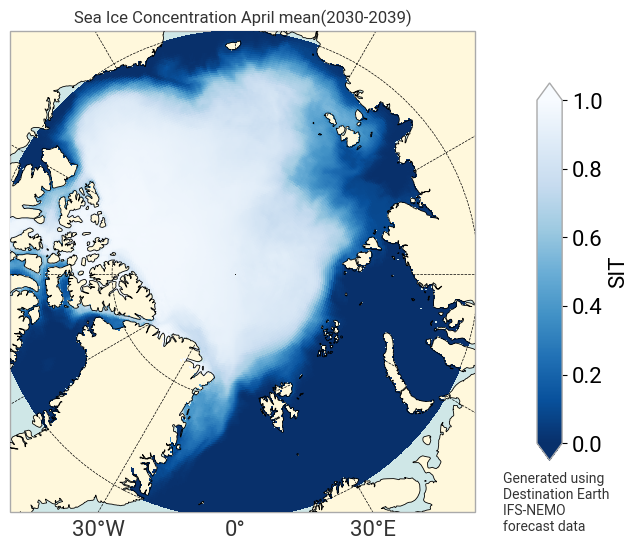

In [35]:
datatoplot=mean_sic
lontoplot=lon
lattoplot=lat
# --- colors (pick what you like) ---
ocean_fc = "#cfe7e7"
land_fc  = "cornsilk"

ax = plt.axes(projection=ccrs.Orthographic(central_longitude=0.0, central_latitude=90))
ax.set_extent([-180, 180, 70, 90], crs=ccrs.PlateCarree())

# 0) ocean base (lowest)
# either set the axes background facecolor:
ax.set_facecolor(ocean_fc)
# (or use the ocean feature)
# ax.add_feature(cfeature.OCEAN, facecolor=ocean_fc, zorder=0)

# 1) land fill (below grid + RIO)
ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=1)

# 2) grid lines (above ocean+land, below RIO)
parallels = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="black",
    alpha=1,
    linestyle="--",
    zorder=2,
)
parallels.ylocator = plt.FixedLocator(range(40, 90, 10))
parallels.xlocator = plt.FixedLocator(range(-180, 180, 30))
parallels.top_labels = False
parallels.xlabel_style = {'fontsize': 16}
parallels.ylabel_style = {'fontsize': 16}

# 3) RIO field (top of fills & grid)
pcolorhandle2 = ax.pcolormesh(
    lontoplot, lattoplot, datatoplot,
    cmap='Blues_r', vmin=0, vmax=1,
    transform=ccrs.PlateCarree(),
    linewidth=0, rasterized=True,
    zorder=3,
)

# 4) coastlines on top for crisp edges
ax.coastlines(resolution="50m", linewidth=0.6, zorder=4)

# colorbar, title, etc. unchanged
cbar = plt.colorbar(pcolorhandle2, shrink=0.7, pad=0.1, aspect=15, extend='both')
cbar.ax.tick_params(labelsize=16)
cbar.set_label('SIT', fontsize=16)
plt.text(2400000,-2300000,'Generated using\nDestination Earth \n'+climateDTmodel+' \nforecast data',fontsize=10)    
plt.title(f"Sea Ice Concentration April mean(2030-2039)")